# Cell annotation and results


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

sc.settings.set_figure_params(dpi=140, facecolor="white", frameon=False)


In [ ]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
SOURCE_DATA_ROOT = Path(
    os.environ.get("EPEN_SOURCE_DATA", REPO_ROOT.parent / "analysis" / "anndata")
).expanduser().resolve()
OUTPUT_ROOT = Path(
    os.environ.get("EPEN_OUTPUT_DIR", REPO_ROOT / "outputs")
).expanduser().resolve()
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SCRIPTS_DIR = REPO_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

def prefer_checkpoint(local_name, source_path):
    local_path = OUTPUT_ROOT / local_name
    return local_path if local_path.exists() else SOURCE_DATA_ROOT / source_path


In [ ]:
COPYKAT_CHECKPOINT = prefer_checkpoint(
    "05_copykat_merged.h5ad", "2000HVG_rg_cc_mt/clustered_niter_with_cnv_cpkat.h5ad"
)
ANNOTATED_CHECKPOINT = OUTPUT_ROOT / "06_annotated.h5ad"

adata2 = sc.read_h5ad(COPYKAT_CHECKPOINT)
adata2


## Leiden clustering at resolution 0.4


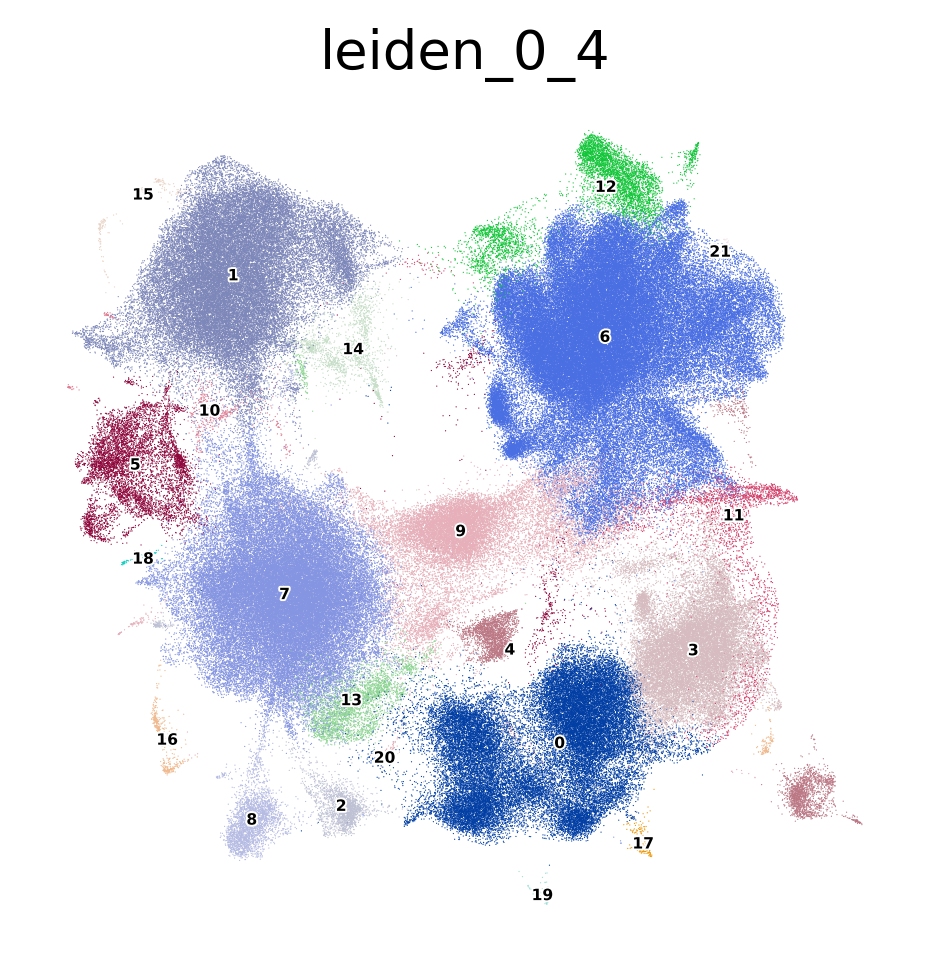

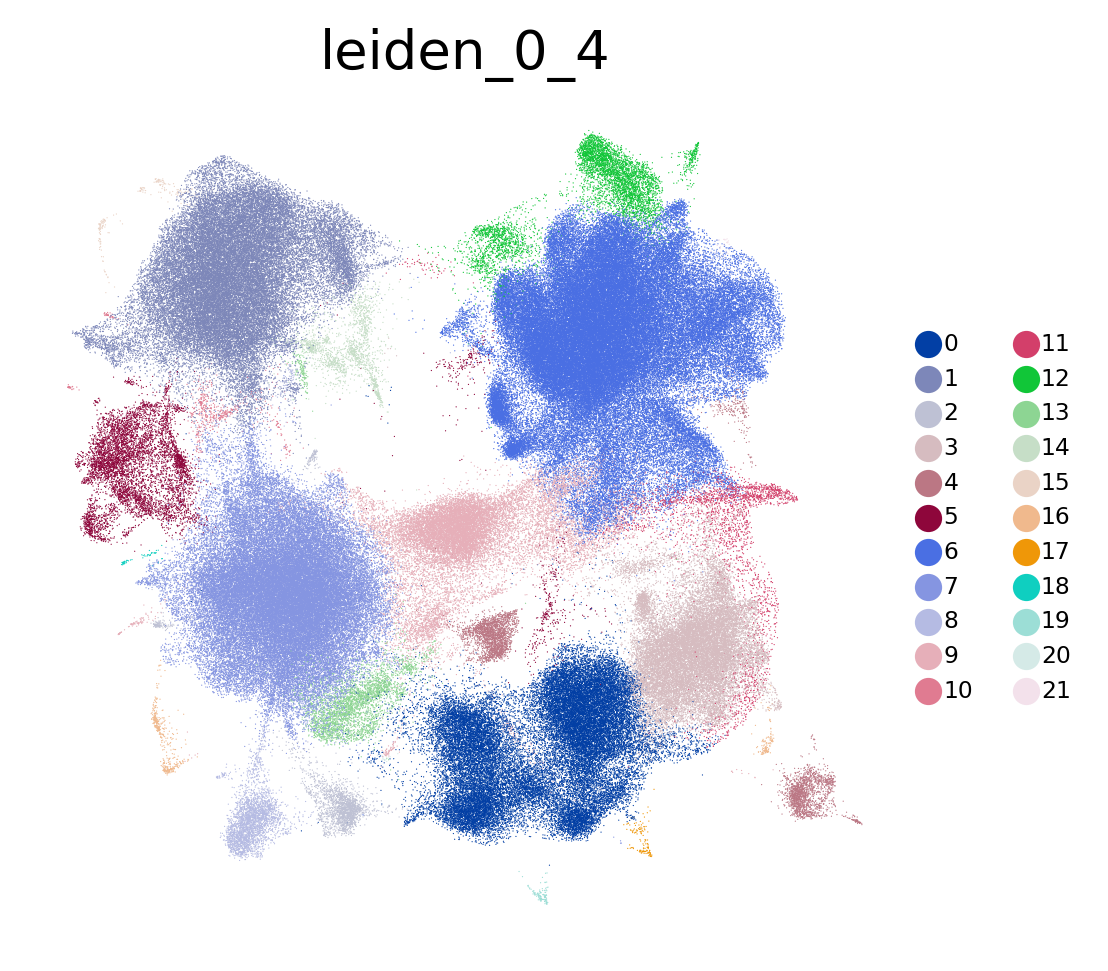

In [ ]:
sc.pl.umap(
        adata2,
        color='leiden_0_4',
        legend_loc="on data",
        legend_fontsize=4,
        legend_fontoutline=1,
    )
sc.pl.umap(
        adata2,
        color=['leiden_0_4'],
        legend_loc="right margin",
        legend_fontsize=6,
        legend_fontoutline=2,
    )

## Canonical marker panels


In [ ]:
leukocyte_markers = {"Leukocyte": ["PTPRC"]}
t_cell_markers = {"T cell": ["CD3D", "CD3E", "CD3G", "CD4", "CD8A", "TRAC", "LCK", "IL7R"]}
b_cell_markers = {"B cell": ["CD19", "MS4A1", "CD22", "CD79A", "CD79B", "IGHM", "IGKC"]}
nk_cell_markers = {"NK cell": ["NCR1", "KLRD1", "NCAM1", "NKG7", "GNLY", "PRF1", "GZMB"]}
astrocyte_markers = {"Astrocyte": ["GFAP", "AQP4", "S100B", "ALDH1L1", "SLC1A3", "SLC1A2"]}
oligo_markers = {"Oligodendrocyte": ["MBP", "PLP1", "MOG", "MAG", "CLDN11"]}
opc_markers = {"OPC": ["PDGFRA", "CSPG4", "OLIG2", "OLIG1", "SOX10", "NKX2-2"]}
endothelial_markers = {"Endothelial": ["CLDN5", "VWF", "FLT1"]}
pericyte_markers = {"Pericyte": ["PDGFRB", "RGS5", "CSPG4", "ANPEP"]}
vsmc_markers = {"vSMC": ["ACTA2", "MCAM", "DES", "TAGLN"]}
fibroblast_markers = {"Fibroblast": ["PDGFRA", "COL1A1", "COL1A2", "FAP"]}
monocyte_markers = {"Monocyte": ["VCAN", "CCR2", "CD14", "FCN1", "LYZ", "S100A8", "S100A9", "S100A12"]}
macrophage_markers = {"Macrophage": ["CD68", "C1QA", "SPP1", "MRC1", "APOE", "APOC1"]}
microglia_markers = {"Microglia": ["P2RY12", "TMEM119", "SALL1", "CX3CR1"]}

all_markers = (
    oligo_markers | opc_markers | endothelial_markers | pericyte_markers |
    vsmc_markers | fibroblast_markers | monocyte_markers |
    macrophage_markers | microglia_markers | t_cell_markers |
    b_cell_markers | nk_cell_markers
)


### Feature plot

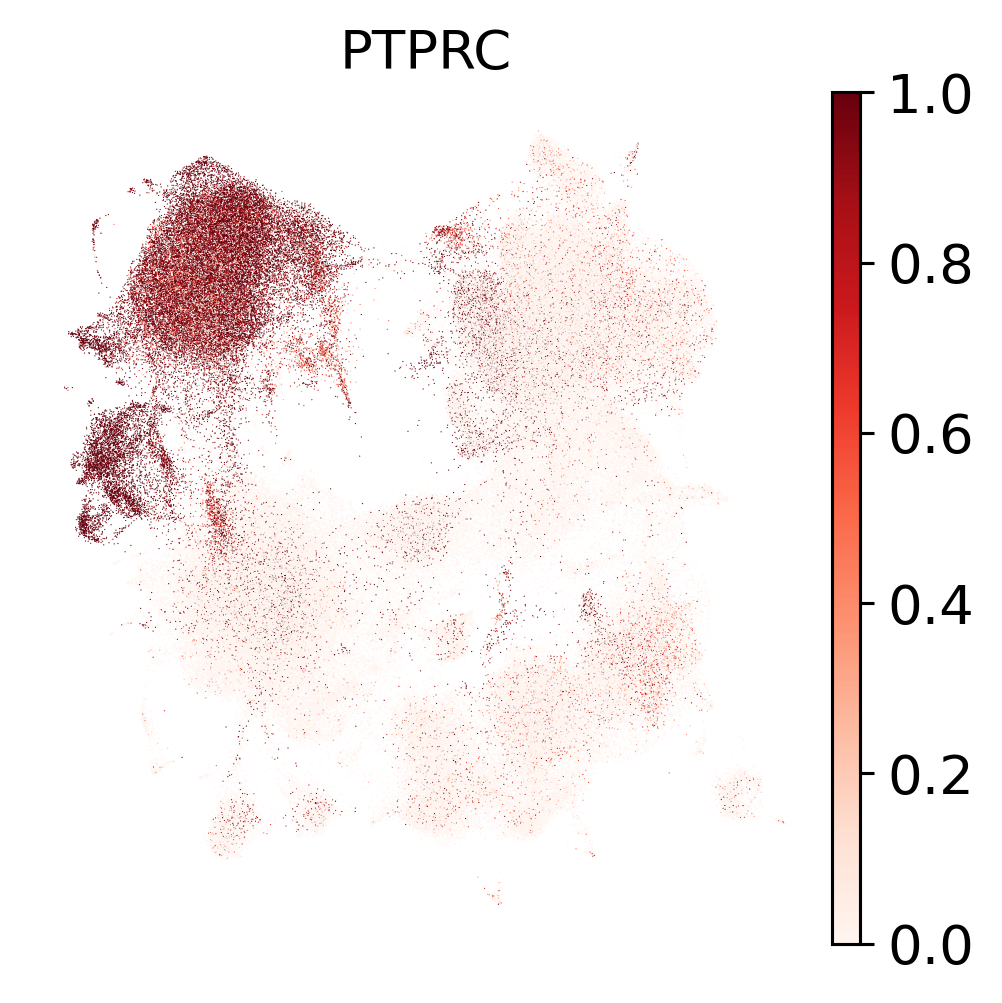

In [ ]:
sc.pl.umap(
        adata2,
        color=leukocyte_markers["Leukocyte"],
        vmin=0,
        vmax=1,  # set vmax to the 99th percentile of the gene count instead of the maximum, to prevent outliers from making expression in other cells invisible. Note that this can cause problems for extremely lowly expressed genes.
        sort_order=False,  # do not plot highest expression on top, to not get a biased view of the mean expression among cells
        frameon=False,
        layer="log1p_norm",
        cmap="Reds",  # or choose another color map e.g. from here: https://matplotlib.org/stable/tutorials/colors/colormaps.html
    )

### Marker dot plot


In [ ]:
marker_overview = (
    macrophage_markers | monocyte_markers | microglia_markers |
    t_cell_markers | astrocyte_markers | pericyte_markers |
    vsmc_markers | endothelial_markers
)


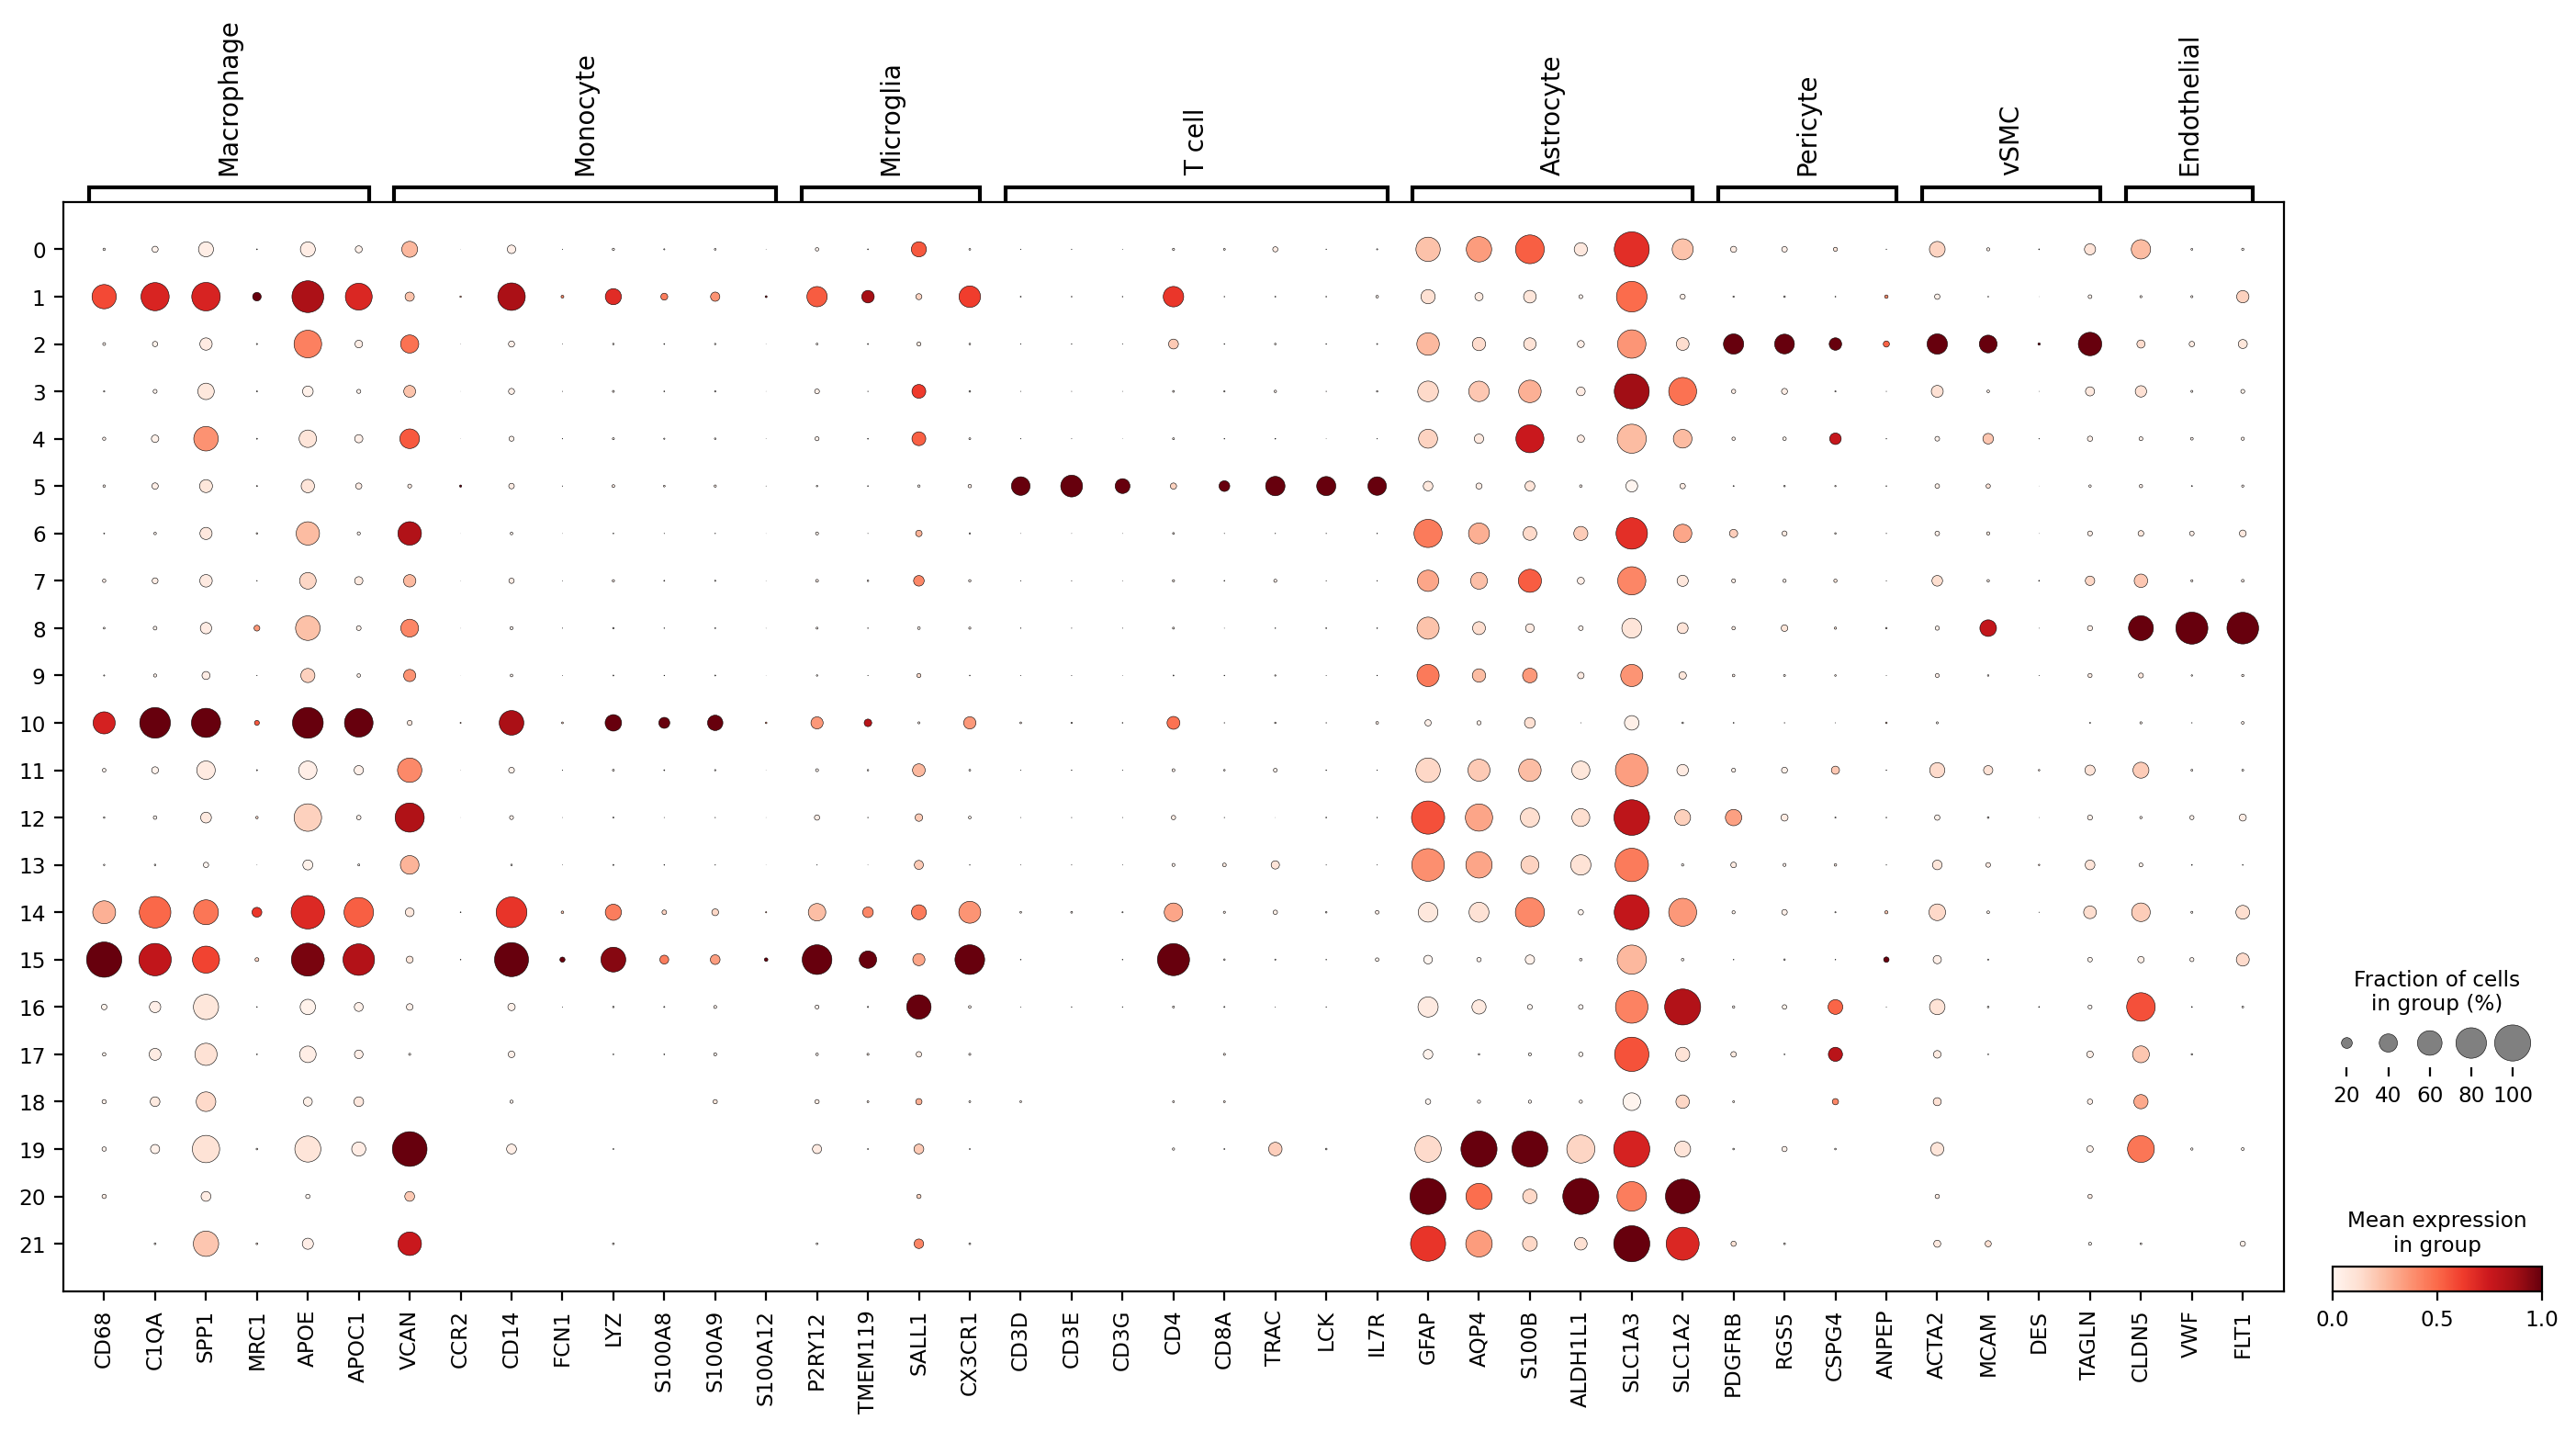

In [ ]:
dp = sc.pl.dotplot(
    adata2,
    var_names=all_markers, 
    groupby="leiden_0_4",
    layer="log1p_norm",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False,
)

## Differential expression


In [ ]:
df = sc.get.rank_genes_groups_df(
    adata2,
    group="0",
    key="rank_genes_groups_leiden_0_4",
    gene_symbols="gene_symbols",
).head(30)
df

,names,scores,logfoldchanges,pvals,pvals_adj,gene_symbols,pct_nz_group,pct_nz_reference
0,PRDX5,179.965881,2.366268,0.0,0.0,PRDX5,0.882724,0.391160
1,AK1,174.730759,2.490159,0.0,0.0,AK1,0.894286,0.426974
2,HSBP1,174.362808,1.915565,0.0,0.0,HSBP1,0.879405,0.363493
3,DYNLL1,173.492157,2.184575,0.0,0.0,DYNLL1,0.925790,0.496558
4,CALM1,173.336182,1.805374,0.0,0.0,CALM1,0.946977,0.606941
5,TUBB4B,172.583359,2.281325,0.0,0.0,TUBB4B,0.894700,0.444495
6,CETN2,172.536972,2.191773,0.0,0.0,CETN2,0.846960,0.315243
7,RBP1,172.530197,2.138950,0.0,0.0,RBP1,0.829507,0.276545
8,TUBA1A,172.483368,1.985842,0.0,0.0,TUBA1A,0.959728,0.646152
9,NUDC,171.103668,1.953487,0.0,0.0,NUDC,0.848564,0.353413


## Gene Ontology enrichment


In [ ]:
import gseapy as gp
de = sc.get.rank_genes_groups_df(adata2, group='0',key='rank_genes_groups_leiden_0_4')
markers = (
    de
    .query("logfoldchanges > 0.25 and pvals_adj < 0.05")
    .sort_values("logfoldchanges", ascending=False)
    ["names"]
    .dropna().drop_duplicates()
    .head(1000)
    .tolist()
)
markers
markers
enr = gp.enrichr(
    gene_list=markers,
    gene_sets="GO_Biological_Process_2021",
    organism="Human",          
    outdir=None,               
    cutoff=0.05               
)
res = enr.res2d
# gp.dotplot(
#     res,
#     size=5,
#     top_term=15,
#     figsize=(3, 7),
#     title="GO Enrichment - Cluster 14"
# )
res.head(20)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,cilium movement (GO:0003341),18/52,2.786799e-11,6.916834e-08,0,0,10.224871,2.485006e+02,SPAG17;CCDC39;DNAI2;RSPH4A;CFAP73;SPEF1;CCDC10...
1,GO_Biological_Process_2021,axoneme assembly (GO:0035082),13/34,3.931591e-09,4.879104e-06,0,0,11.903652,2.303859e+02,SPAG16;SPAG17;CCDC39;RSPH4A;SPEF1;DNAAF3;CCDC1...
2,GO_Biological_Process_2021,"mitochondrial electron transport, NADH to ubiq...",11/39,2.128691e-06,1.761137e-03,0,0,7.536184,9.842259e+01,NDUFA7;NDUFB7;NDUFS8;NDUFB10;NDUFA12;NDUFA4;ND...
3,GO_Biological_Process_2021,aerobic electron transport chain (GO:0019646),14/70,7.828963e-06,3.850422e-03,0,0,4.803245,5.647503e+01,NDUFA7;NDUFB7;NDUFB10;NDUFA12;NDUFA4;NDUFC2;ND...
4,GO_Biological_Process_2021,cilium assembly (GO:0060271),35/314,8.103579e-06,3.850422e-03,0,0,2.433692,2.853067e+01,DYNC2I2;SPAG16;CETN2;CEP19;DCTN3;RSPH9;CFAP206...
...,...,...,...,...,...,...,...,...,...,...
2477,GO_Biological_Process_2021,"regulation of transcription, DNA-templated (GO...",57/2244,9.999933e-01,9.999958e-01,0,0,0.464686,3.133649e-06,FOXA1;MESP1;HMX3;NAT14;SOX2;HINT1;ZIC2;ZIC3;RU...
2478,GO_Biological_Process_2021,regulation of transcription by RNA polymerase ...,59/2206,9.999933e-01,9.999958e-01,0,0,0.492161,3.307457e-06,FOXA1;MESP1;HMX3;CD81;PARK7;SOX2;CHCHD2;EDNRB;...
2479,GO_Biological_Process_2021,cellular protein modification process (GO:0006...,17/1025,9.999945e-01,9.999958e-01,0,0,0.308684,1.710331e-06,DSP;PSMD10;ANXA1;NRK;FBXW9;PPM1J;PARK7;CHRDL1;...
2480,GO_Biological_Process_2021,protein phosphorylation (GO:0006468),4/496,9.999955e-01,9.999958e-01,0,0,0.151076,6.804710e-07,MUSK;NRK;GTF2H5;MYLK3


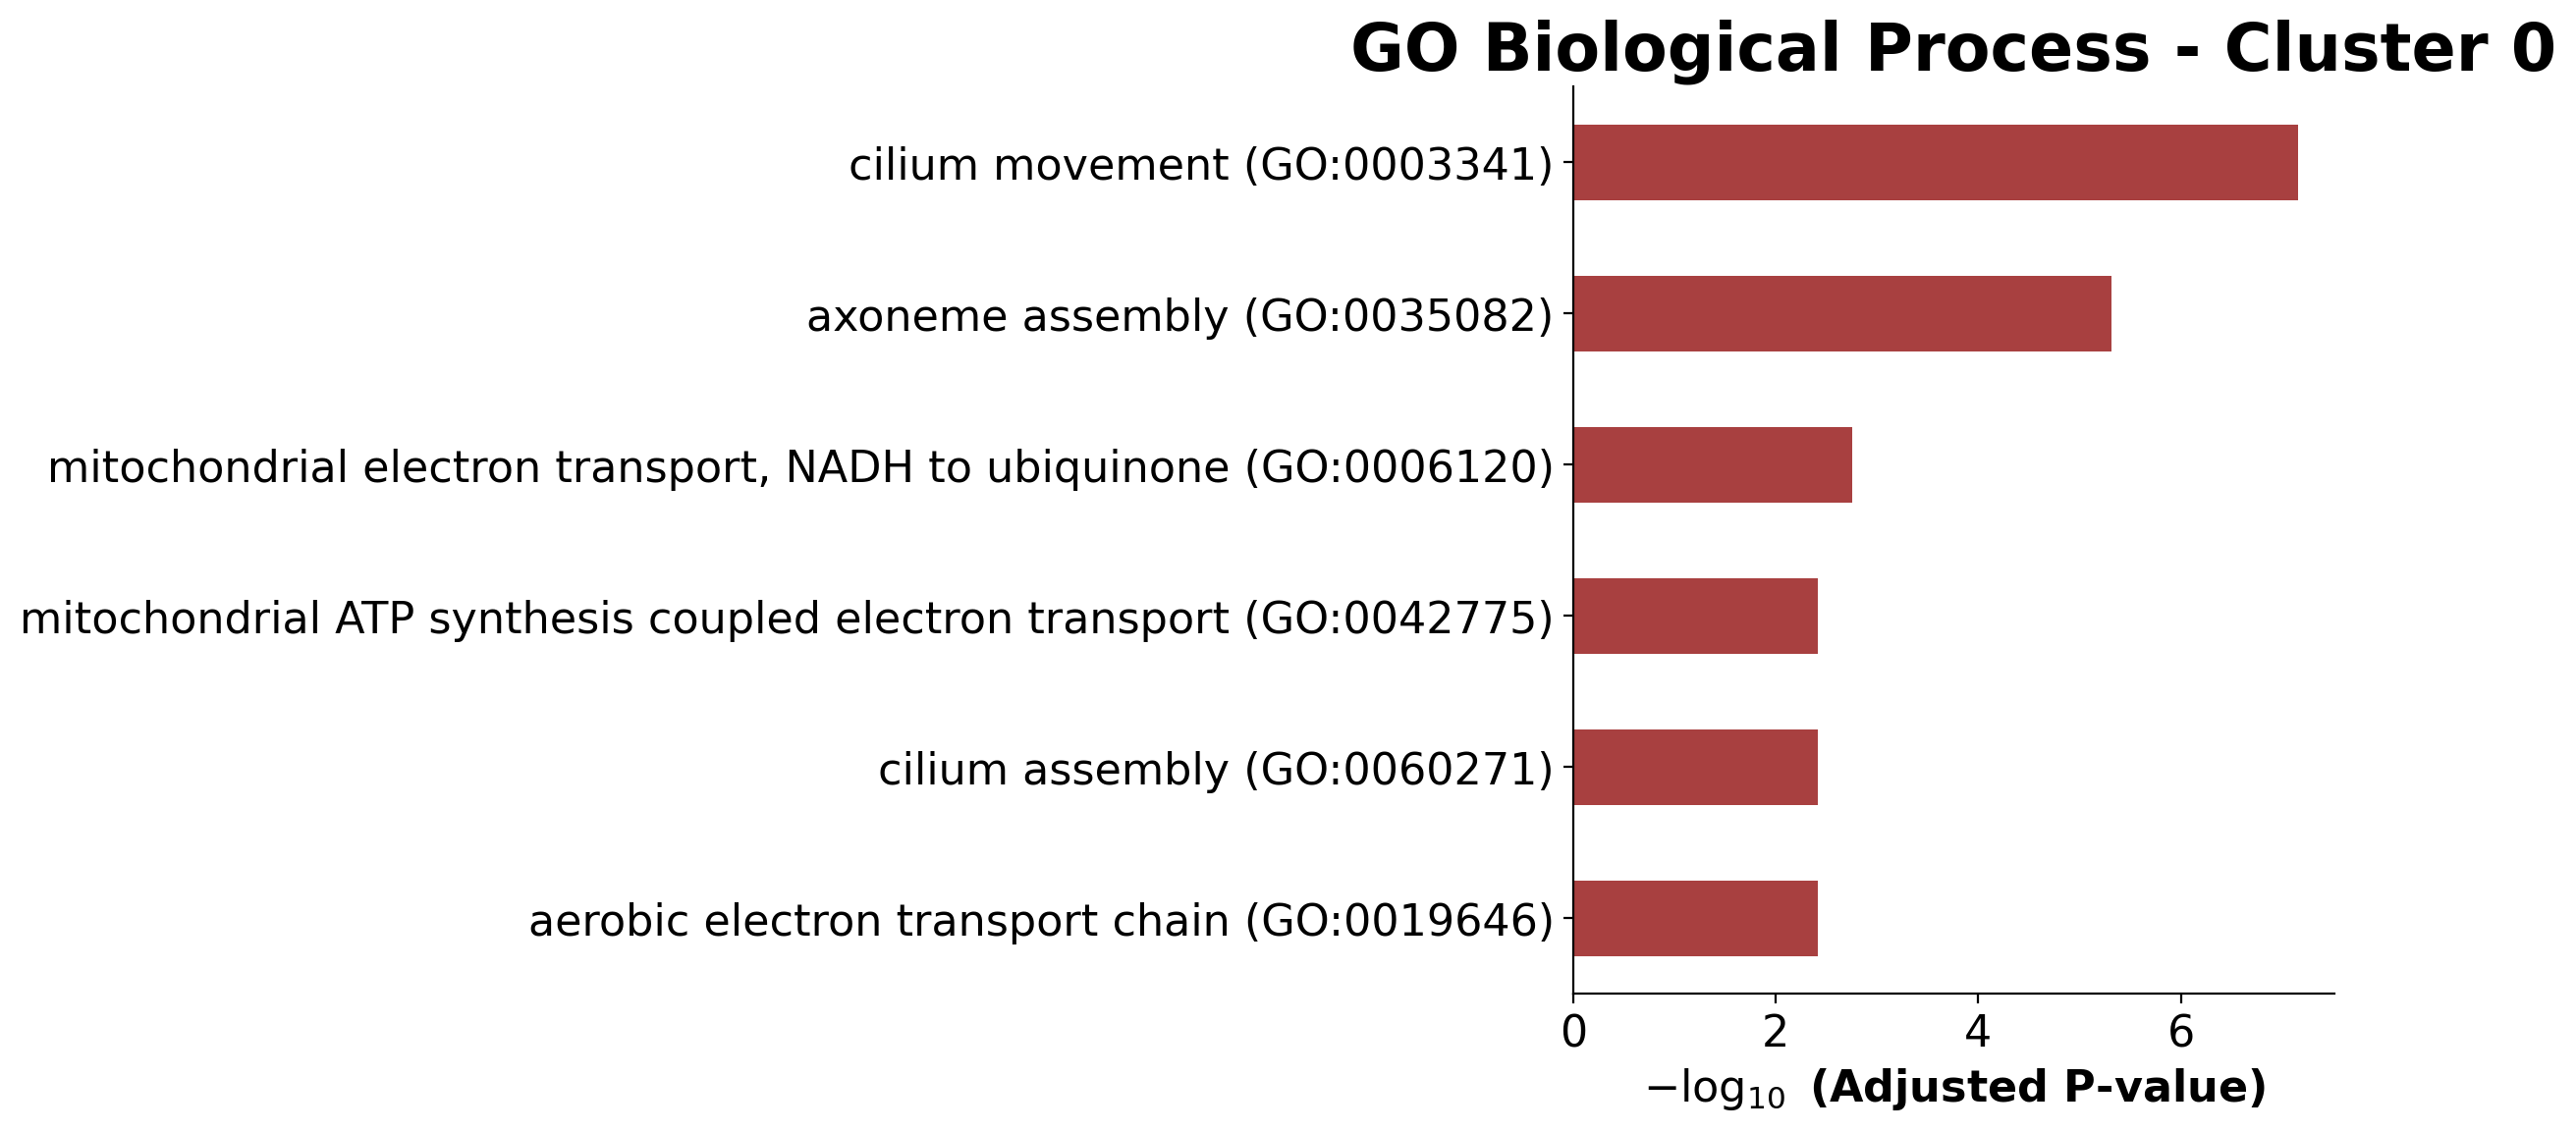

In [ ]:
ax = gp.barplot(res,
             column="Adjusted P-value",        # group for multi-sample comparison
             size=10,
             top_term=10,
             figsize=(5, 6),
             color='darkred',
             title="GO Biological Process - Cluster 0")

plt.show()

## Cluster annotation


In [ ]:
cluster_col = "leiden_0_4"

cluster_to_label = {
    "1": "myeloid",
    "10": "myeloid",
    "15": "myeloid",
    "5": "T cell",
    "8": "endothelial",
    "4": "oligodendrocyte",
    "16": "neuron",
    "18": "neuron",
    "2": "mural cells",
    "13": "neuron",
    "19": "ependymal",
    "6": "neuronal-like malignant",
    "21": "neuronal-like malignant",
    "12": "neuronal-like malignant",
    "11": "cycling cells",
    "20": "astrocyte",
    "14": "myeloid-mimicry malignant",
    "9": "stressed malignant",
    "7": "translation-high malignant",
    "0": "ependymal-like malignant",
    "3": "ependymal-like malignant",
    "17": "neuronal-like malignant",
}

adata2.obs["cell_type_leiden_0_4_cluster_manual"] = (
    adata2.obs[cluster_col].astype(str).map(cluster_to_label)
)

In [ ]:
label_key = "cell_type_leiden_0_4_cluster_manual"
adata2.obs[label_key] = adata2.obs[label_key].astype("category")

color_map = {
    "ependymal-like malignant": "#d6bcc0",
    "cycling cells": "#e07b91",
    "oligodendrocyte": "#bb7784",
    "neuronal-like malignant": "#4a6fe3",
    "translation-high malignant": "#8595e1",
    "stressed malignant": "#e6afb9",
    "neuron": "#f0b98d",
    "ependymal": "#9cded6",
    "astrocyte": "#d5eae7",
    "mural cells": "#bec1d4",
    "endothelial": "#b5bbe3",
    "myeloid-mimicry malignant": "#c6dec7",
    "myeloid": "#7d87b9",
    "T cell": "#8e063b",
}
adata2.uns[f"{label_key}_colors"] = [
    color_map[label] for label in adata2.obs[label_key].cat.categories
]

malignant_clusters = {"0", "3", "6", "7", "9", "12", "14", "17", "18", "21"}
adata2.obs["malignancy_leiden_0_4"] = np.where(
    adata2.obs["leiden_0_4"].astype(str).isin(malignant_clusters),
    "tumor",
    "normal",
)


## Annotated cell types


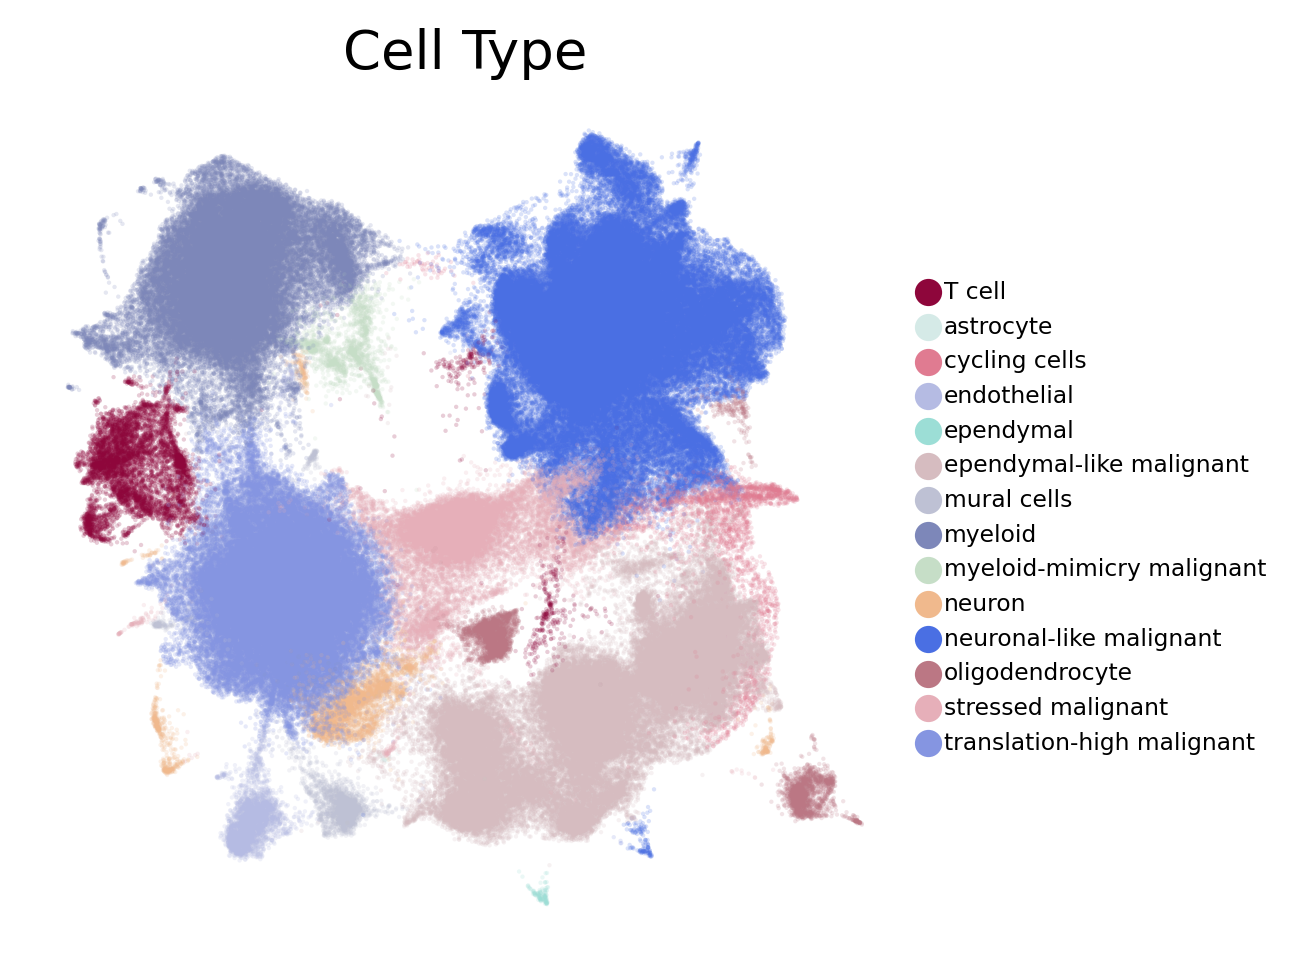

In [ ]:
sc.pl.umap(
    adata2,
    color="cell_type_leiden_0_4_cluster_manual",
    title="Cell Type",
    legend_loc="right margin",
    legend_fontsize=6,
    legend_fontoutline=1,
    size=5,
    alpha=0.2,
    frameon=False,
)

## CopyKAT prediction on UMAP


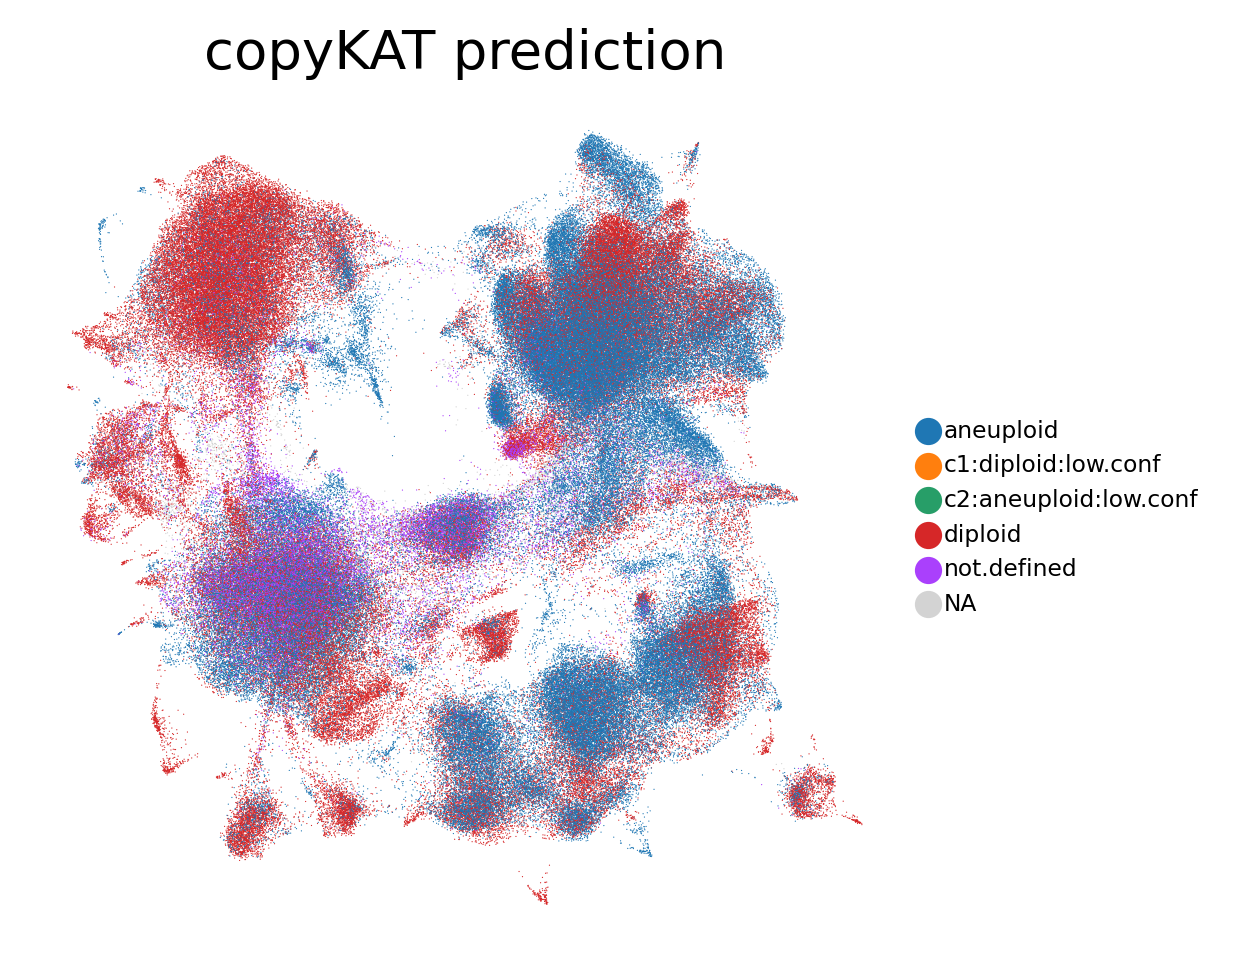

In [ ]:
sc.pl.umap(
        adata2,
        color='copykat_pred',
        legend_loc="right margin",
        legend_fontsize=6,
        legend_fontoutline=2,
        title = "copyKAT prediction",
    )

## Save annotated data


In [ ]:
adata2.write_h5ad(ANNOTATED_CHECKPOINT, compression="gzip")
ANNOTATED_CHECKPOINT
